# Penrose Tiling from Five Dimensions

The approach taken in the projection follows from the book "Quasicrystals and Geometry" by Marjorie Senechal.
Logic is similar to that outlined in the Mathematica notebook shown in the youtube video by NumberCruncher, "Penrose Tilings from Five Dimensions", https://www.youtube.com/watch?v=jJOTM2UGx70&t=323s
 


In [1]:
# Set to explore tenfold symmetry
tenFold = False
# tenFold = True

In [2]:
# %matplotlib widget

import sys
sys.path.insert(0, '..')

import numpy as np

from scipy.spatial import ConvexHull

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Rectangle, Circle, Polygon

from sympy import symbols, Rational, Integer

from ji_tiling import basis2D, subSet, in_hull, unitVector, polygonDataFunction, nMemberQ

### Define 5D rotation and find eigenvectors

In [3]:

# Senechal, use to explore 10 fold symmetry below
# if tenFold:
#     rotationMatrix = np.array([[0.,0.,0.,0.,1.],[1.,0.,0.,0.,0.],[0.,1.,0.,0.,0.],[0.,0.,1.,0.,0.],[0.,0.,0.,1.,0.]])
# else:
#     rotationMatrix = np.array([[0.,1.,0.,0.,0.],[0.,0.,1.,0.,0.],[0.,0.,0.,1.,0.],[0.,0.,0.,0.,1.],[1.,0.,0.,0.,0.]])    

rotationMatrix = np.array([[0.,0.,0.,0.,1.],[1.,0.,0.,0.,0.],[0.,1.,0.,0.,0.],[0.,0.,1.,0.,0.],[0.,0.,0.,1.,0.]])

eigenValues, eigenVectors = np.linalg.eig(rotationMatrix)

for i in range(5):
    print(i)
    print('  :', eigenVectors[:,i].real ) #/np.linalg.norm(eigenVectors[:,i].real) )
    if (i<4):
        print('  :',  eigenVectors[:,i].imag ) #/np.linalg.norm(eigenVectors[:,i].imag) )

0
  : [-0.1381966 -0.1381966  0.3618034 -0.4472136  0.3618034]
  : [-0.4253254   0.4253254  -0.26286556  0.          0.26286556]
1
  : [-0.1381966 -0.1381966  0.3618034 -0.4472136  0.3618034]
  : [ 0.4253254  -0.4253254   0.26286556 -0.         -0.26286556]
2
  : [ 0.4472136  0.1381966 -0.3618034 -0.3618034  0.1381966]
  : [ 0.         -0.4253254  -0.26286556  0.26286556  0.4253254 ]
3
  : [ 0.4472136  0.1381966 -0.3618034 -0.3618034  0.1381966]
  : [-0.          0.4253254   0.26286556 -0.26286556 -0.4253254 ]
4
  : [0.4472136 0.4472136 0.4472136 0.4472136 0.4472136]


In [4]:
eigenValues

array([-0.80901699+0.58778525j, -0.80901699-0.58778525j,
        0.30901699+0.95105652j,  0.30901699-0.95105652j,
        1.        +0.j        ])

### Projector and 3D basis used to construct convex hull.

Following the clear explanation by Dugan Hammock at 40'55s in https://youtu.be/SPXceXPm9Wg?si=N7bosvtZWSwlN1VB
:
 the question as to whether a 5D cell lies in the 2D projection plane is equivalent to asking if the cell exists as a 3D volume in the perpendicular space.

In [5]:
# The projection plane
print('2D projection plane:')
p = basis2D(eigenVectors,3,2)

# The cut window
# 3D space of second projection plane (orthogonal to first) and vector [1,1,1,1,1]
print('3D space orthogonal to above projection plane:')
y = np.vstack((
    basis2D(eigenVectors,0,1),
    np.array([1,1,1,1,1])/np.linalg.norm(np.array([1,1,1,1,1]))
))

2D projection plane:
-->5D basis vectors are rotated in 2D plane by (2.0π)/5
3D space orthogonal to above projection plane:
-->5D basis vectors are rotated in 2D plane by (3.9999999999999996π)/5


In [6]:
print(p)

[[ 0.63245553  0.19543951 -0.51166727 -0.51166727  0.19543951]
 [ 0.         -0.60150096 -0.37174803  0.37174803  0.60150096]]


In [7]:
print(y)

[[-0.19543951 -0.19543951  0.51166727 -0.63245553  0.51166727]
 [ 0.60150096 -0.60150096  0.37174803  0.         -0.37174803]
 [ 0.4472136   0.4472136   0.4472136   0.4472136   0.4472136 ]]


In [8]:
cell = np.zeros((32,5))
# Delaunay cell with close boundary on zero faces, "open" on other faces
s = 0.999
i = 0
for i5 in range(2):
    for i4 in range(2):
        for i3 in range(2):
            for i2 in range(2):
                for i1 in range(2):
                    cell[i,:] = s*np.array([i1,i2,i3,i4,i5])
                    i += 1

# For testing specification of Voronoi cell in posing 3D perpendicular space
if (tenFold):
    cell -= 0.5

convexHullSeed = (y@cell.T).T

# Translating the seed provides for more of the ratios in Erv Wilson's Hexadic Diamond
# convexHullSeed[:,2] -= 1

hull = ConvexHull(convexHullSeed)

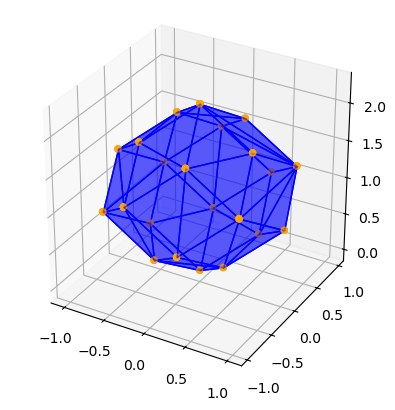

In [9]:
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")

pts = convexHullSeed

for s in hull.simplices:
    tri = Poly3DCollection([pts[s]])
    tri.set_color('blue')
    tri.set_alpha(0.4)
    ax.add_collection3d(tri)
    ax.scatter(pts[s, 0], pts[s, 1], pts[s, 2], marker='o', color='orange')
ax.set_box_aspect([1.0, 1.0, 1.0])

### Select points in convex hull

In [34]:
# To see 10 fold symmetry with Voronoi cell centered on zero is used to develop convex hull
if (tenFold):
    shiftVector = np.array((0.,0.,0.,0.,0.))
else:
    # shiftVector = np.array((0.8,-0.2,-0.2,-0.2,-0.2))
    # shiftVector = np.array( (0,1,2,3,-(1+2+3)) ) / (2+np.sqrt(5))
    # To optimize points from Eikosany tuning
    shiftVector = np.array([np.float64(-0.36844), np.float64(-0.491094), np.float64(0.315972), np.float64(0.430247), np.float64(0.113314)])


print(f'Shift vector projected onto (perpendicular) cut space: {y@shiftVector}')

d = 3
z5 = np.zeros(((2*d+1)**5,5))
i = 0
for i5 in range(-d,d+1):
    for i4 in range(-d,d+1):
        for i3 in range(-d,d+1):
            for i2 in range(-d,d+1):
                for i1 in range(-d,d+1):
                    z5[i,:] = np.array([i1,i2,i3,i4,i5]) + shiftVector
                    i += 1

z5Projected = (y@z5.T).T

inHullIndices = in_hull(z5Projected,convexHullSeed[hull.vertices])

selPoints = z5[inHullIndices,:]

Shift vector projected onto (perpendicular) cut space: [ 1.15526404e-01  1.49114211e-01 -4.47213595e-07]


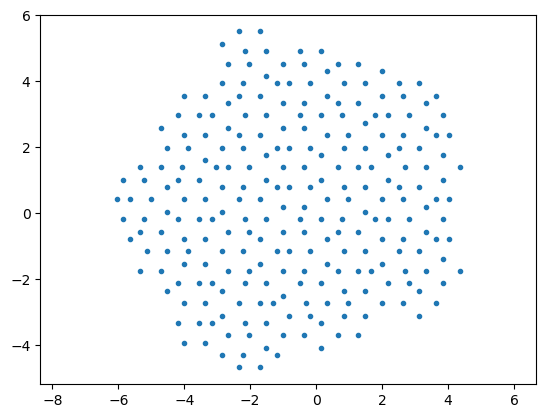

In [35]:
# Plot the point within the volume
xy = (p@selPoints.T).T

plt.figure()
plt.plot(xy[:,0],xy[:,1],'.')
plt.axis('equal')
plt.show()

### Construct the tiling

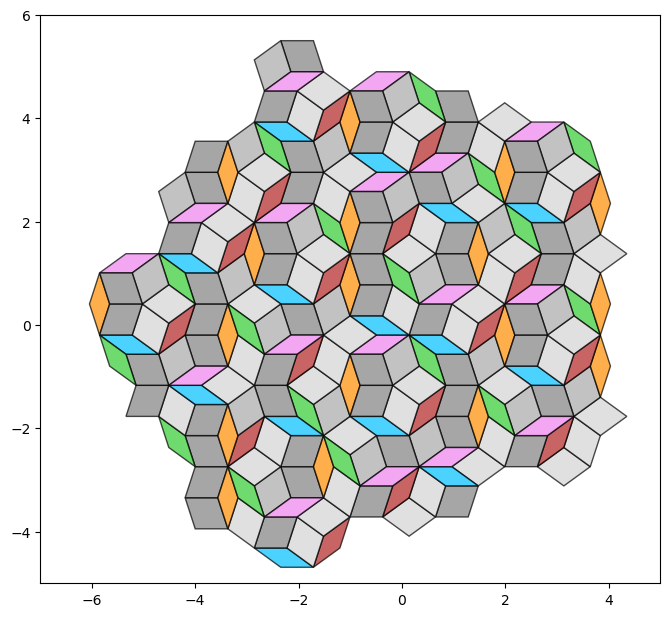

In [36]:
spans = list(subSet([0,1,2,3,4],2))
e = np.identity(5)

clrs = ['grey','violet','deepskyblue','grey','darkgrey','limegreen','darkorange','lightgrey',
 'firebrick',
 'lightgrey'
 ]

# clrs = ['yellow','green','green','yellow','yellow','green','green','yellow',
#  'green',
#  'yellow'
#  ]

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(-7, 5)
ax.set_ylim(-5, 6)
ax.set_aspect('equal')

n_tiles = 0

for pt in selPoints:
    for d_, dir_ in enumerate(spans):
        tile = polygonDataFunction(pt,dir_)
        in_base = np.all((
            nMemberQ(selPoints,tile[0]),
            nMemberQ(selPoints,tile[1]),
            nMemberQ(selPoints,tile[2]),
            nMemberQ(selPoints,tile[3]))
                        )
        if in_base:
            t = (p@tile.T).T
            polygon = Polygon(t, 
                  edgecolor='black', facecolor=clrs[d_],alpha=0.7)
            ax.add_patch(polygon)

            n_tiles += 1        

### Write out files for use in supercollider

In [32]:
tileCoordinates = np.zeros((n_tiles,8))
tileIndices = np.zeros((n_tiles,20))
tileFaceDirection = np.zeros((n_tiles))

n_ = 0

for pt in selPoints:
    for d_, dir_ in enumerate(spans):
        tile = polygonDataFunction(pt,dir_)
        in_base = np.all((
            nMemberQ(selPoints,tile[0]),
            nMemberQ(selPoints,tile[1]),
            nMemberQ(selPoints,tile[2]),
            nMemberQ(selPoints,tile[3]))
                        )
        if in_base:
            t = (p@tile.T).T

            tileCoordinates[n_,0:2] = t[0,:]
            tileCoordinates[n_,2:4] = t[1,:]
            tileCoordinates[n_,4:6] = t[3,:]   # note reordering to be consistent with supercollider code convention
            tileCoordinates[n_,6:8] = t[2,:]
            
            t_ = (tile-shiftVector).astype(int)
            tileIndices[n_,0:5]   = t_[0,:]
            tileIndices[n_,5:10]  = t_[1,:]
            tileIndices[n_,10:15] = t_[3,:]   # note reordering to be consistent with supercollider code convention
            tileIndices[n_,15:20] = t_[2,:]

            tileFaceDirection[n_] = d_
            
            n_ += 1


In [14]:
#  Don't update for now...
# if (not tenFold):
#     dir = '../Data/'
#     np.savetxt(dir+'verts_5Dprojection.txt',tileCoordinates,fmt='%.8e',delimiter=',')
#     np.savetxt(dir+'indices_5Dprojection.txt',tileIndices,fmt='%d',delimiter=',')
#     np.savetxt(dir+'faces_5Dprojection.txt',tileFaceDirection,fmt="%d")

### Plot points present in Erv Wilson's Hexadic Diamond and Eikosany

**Hexadic Diamond** (blue): at most one positive and one negative coordinate — A₄ roots (εᵢ−εⱼ) and weights (±εᵢ).

**Eikosany** (red): all coordinates in {0,1}, exactly 2 or 3 positive — products of 2 or 3 generators from {1,3,5,7,9,11}. C(6,3)=20 points.

In [43]:
r_eiko

['15/8',
 '35/32',
 '105/64',
 '45/32',
 '135/128',
 '63/32',
 '315/256',
 '15/8',
 '27/16',
 '45/32',
 '135/128',
 '63/32']

Hexadic Diamond points found: 7
Eikosany points found:        12


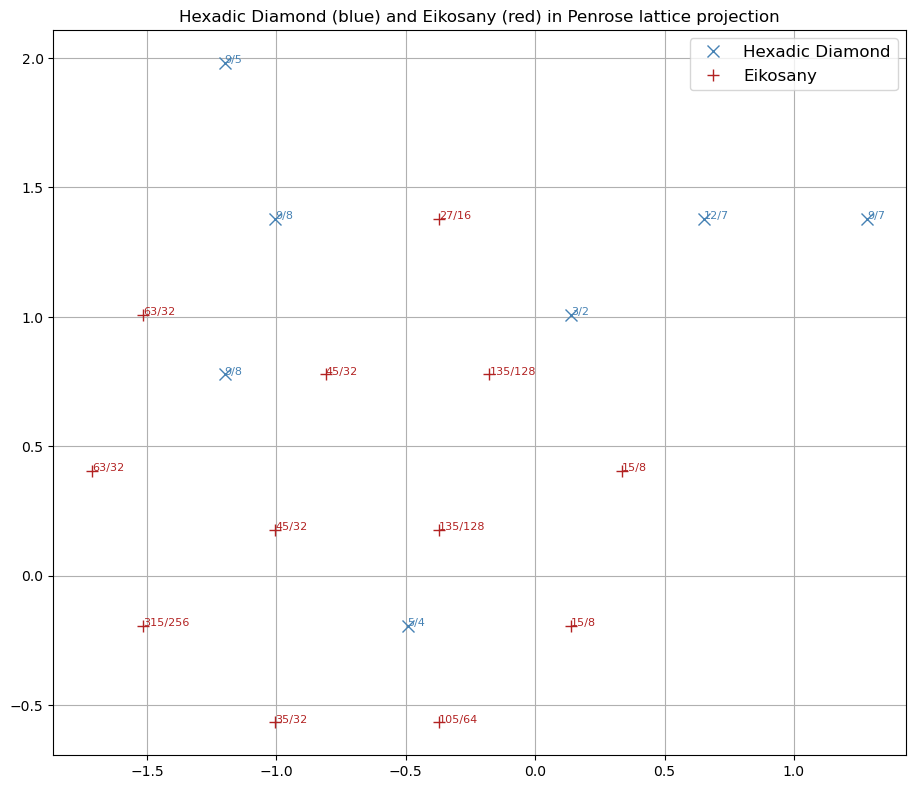

In [37]:
rI = np.array([3, 5, 7, 9, 11])

diamond_ratios = set([
    Rational(3,2), Rational(16,9), Rational(5,4), Rational(16,11),
    Rational(7,4), Rational(4,3), Rational(9,8), Rational(8,5),
    Rational(11,8), Rational(8,7),
    Rational(10,7), Rational(12,11), Rational(14,9), Rational(5,3),
    Rational(18,11), Rational(7,5), Rational(11,6), Rational(9,7),
    Rational(6,5), Rational(11,9),
    Rational(12,9), Rational(10,9), Rational(20,11), Rational(14,11),
    Rational(7,6), Rational(9,6), Rational(9,5), Rational(11,10),
    Rational(11,7), Rational(12,7),
    Rational(1)
])

xy_diamond, r_diamond = [], []
xy_eiko, r_eiko = [], []

for pt in selPoints:
    pt5 = (pt - shiftVector).astype(int)

    # --- Hexadic Diamond ---
    # A4 roots (one +1, one -1) and weights (one ±1): at most 1 positive, at most 1 negative
    if np.sum(pt5 > 0) <= 1 and np.sum(pt5 < 0) <= 1:
        # pS = (Rational(rI[0],1)**Integer((pt5[0]%2)*np.sign(pt5[0])) *
        #       Rational(rI[1],1)**Integer((pt5[1]%2)*np.sign(pt5[1])) *
        #       Rational(rI[2],1)**Integer((pt5[2]%2)*np.sign(pt5[2])) *
        #       Rational(rI[3],1)**Integer((pt5[3]%2)*np.sign(pt5[3])) *
        #       Rational(rI[4],1)**Integer((pt5[4]%2)*np.sign(pt5[4])))
        pS = (Rational(rI[0],1)**Integer(pt5[0]) *
              Rational(rI[1],1)**Integer(pt5[1]) *
              Rational(rI[2],1)**Integer(pt5[2]) *
              Rational(rI[3],1)**Integer(pt5[3]) *
              Rational(rI[4],1)**Integer(pt5[4]))
        while pS > 2: pS /= 2
        while pS < 1: pS *= 2
        if pS in diamond_ratios:
            r_diamond.append(str(pS))
            xy_diamond.append(p @ pt)

    # --- Eikosany ---
    # Products of 2 or 3 generators from {1,3,5,7,9,11}: coords in {0,1}, sum in {2,3}
    # (choosing "1" from the generator set contributes no exponent, so sum=2 means 1×hᵢ×hⱼ)
    if np.all(pt5 >= 0) and np.all(pt5 <= 1) and 2 <= np.sum(pt5) <= 3:
        pS = Rational(1)
        for k in range(5):
            if pt5[k] == 1:
                pS *= Rational(int(rI[k]), 1)
        while pS > 2: pS /= 2
        while pS < 1: pS *= 2
        r_eiko.append(str(pS))
        xy_eiko.append(p @ pt)

xy_diamond = np.asarray(xy_diamond) if xy_diamond else np.zeros((0,2))
xy_eiko    = np.asarray(xy_eiko)    if xy_eiko    else np.zeros((0,2))

print(f'Hexadic Diamond points found: {len(r_diamond)}')
print(f'Eikosany points found:        {len(r_eiko)}')

fig, ax = plt.subplots(figsize=(11, 11))

if len(xy_diamond):
    ax.plot(xy_diamond[:,0], xy_diamond[:,1], 'x', color='steelblue',
            markersize=8, label='Hexadic Diamond', zorder=3)
    for i, rl in enumerate(r_diamond):
        ax.annotate(rl, xy=xy_diamond[i], textcoords='data',
                    fontsize=8, color='steelblue')

if len(xy_eiko):
    ax.plot(xy_eiko[:,0], xy_eiko[:,1], '+', color='firebrick',
            markersize=8, label='Eikosany', zorder=3)
    for i, rl in enumerate(r_eiko):
        ax.annotate(rl, xy=xy_eiko[i], textcoords='data',
                    fontsize=8, color='firebrick')

ax.legend(fontsize=12)
ax.grid(True)
ax.set_aspect('equal')
plt.title('Hexadic Diamond (blue) and Eikosany (red) in Penrose lattice projection')
plt.show()

### Optimize shiftVector to maximise Hexadic Diamond nodes in the tiling

The 31 Diamond lattice vectors are fixed points in ℤ⁵. A lattice point **n** is
selected by the cut-and-project window when **(n + sv)** projected onto the
perpendicular space E⊥ falls inside the convex hull. We search over sv (with
the A₄ constraint Σᵢsvᵢ = 0) to maximise how many of the 31 Diamond vectors
satisfy this condition.

The Delaunay triangulation of the hull is precomputed once; each objective
evaluation then checks only 31 points, making the search fast.

In [38]:
from scipy.optimize import differential_evolution
from scipy.spatial import Delaunay

# --- Build the 31 Hexadic Diamond lattice vectors in ℤ⁵ ---
# Origin, ±εᵢ (weights), εᵢ−εⱼ (A₄ roots)
_diamond_set = set()
_diamond_set.add((0, 0, 0, 0, 0))
for _i in range(5):
    _ei  = [0]*5; _ei[_i]  =  1; _diamond_set.add(tuple(_ei))
    _ei  = [0]*5; _ei[_i]  = -1; _diamond_set.add(tuple(_ei))
    for _j in range(5):
        if _j != _i:
            _eij = [0]*5; _eij[_i] = 1; _eij[_j] = -1
            _diamond_set.add(tuple(_eij))

diamond_vecs = np.array(sorted(_diamond_set), dtype=float)  # (31, 5)
print(f'Diamond lattice vectors: {len(diamond_vecs)}  (expect 31)')

# --- Precompute Delaunay triangulation of the convex hull (done once) ---
hull_delaunay = Delaunay(convexHullSeed[hull.vertices])

# --- Objective: negative Diamond count (minimise → maximise count) ---
def neg_diamond_count(sv_free):
    """sv_free: 4 free components; 5th enforces Σᵢsvᵢ = 0."""
    sv = np.append(sv_free, -sv_free.sum())
    projected = (y @ (diamond_vecs + sv).T).T      # (31, 3) in E⊥
    return -(hull_delaunay.find_simplex(projected) >= 0).sum()

# --- Baseline: current shiftVector ---
sv_current = shiftVector          # set in earlier cell
sv0_free   = sv_current[:4]
baseline   = -int(neg_diamond_count(sv0_free))
print(f'Baseline Diamond count (current shiftVector {np.round(sv_current,3)}): {baseline}')

# --- Global optimisation over sv ∈ [−0.5, 0.5]⁴, sv₄ = −Σsv₀₋₃ ---
# Bounds keep each component in (−0.5, 0.5); the A₄ hyperplane constraint
# Σ = 0 is enforced implicitly by computing sv[4] = −sv[0:4].sum().
bounds = [(-0.5, 0.5)] * 4

result = differential_evolution(
    neg_diamond_count,
    bounds,
    seed        = 42,
    maxiter     = 500,
    popsize     = 20,
    tol         = 0,          # run full budget; objective is integer-valued
    polish      = True,
    disp        = False,
)

sv_opt_free = result.x
sv_opt      = np.append(sv_opt_free, -sv_opt_free.sum())
best_count  = -int(result.fun)

print(f'\nOptimal shiftVector : {np.round(sv_opt, 6)}')
print(f'Diamond nodes found : {best_count}  (baseline: {baseline})')
print(f'Improvement         : {best_count - baseline}')
print(f'\nTo use: replace shiftVector in the cell above with')
print(f'  shiftVector = np.array({list(np.round(sv_opt, 6))})')

Diamond lattice vectors: 31  (expect 31)
Baseline Diamond count (current shiftVector [-0.368 -0.491  0.316  0.43   0.113]): 2

Optimal shiftVector : [ 0.367096 -0.063792  0.208207 -0.139523 -0.371988]
Diamond nodes found : 2  (baseline: 2)
Improvement         : 0

To use: replace shiftVector in the cell above with
  shiftVector = np.array([np.float64(0.367096), np.float64(-0.063792), np.float64(0.208207), np.float64(-0.139523), np.float64(-0.371988)])


### Diagnostic: theoretical maximum Diamond nodes and E⊥ landscape

For each of the 31 Diamond vectors **n**ₖ, we ask: *if we centred the hull on
**n**ₖ, how many other Diamond vectors would also fall inside?*  This exhaustive
check gives the true upper bound on Diamond nodes for any shift, and reveals
whether the current shift is already optimal or the optimiser missed something.

A heat-map of counts over a fine grid of sv values shows the full landscape.

Theoretical maximum (anchor search): 2 Diamond nodes
Best anchor vector : [-1  0  0  0  0]
Corresponding sv   : [ 0.8 -0.2 -0.2 -0.2 -0.2]
Current baseline   : 2

→ Current shift already achieves the theoretical maximum.
  The hull is too small to contain more Diamond nodes simultaneously.
  Consider enlarging d (lattice range) or scaling the Delaunay cell.

Grid search maximum : 2
Grid search minimum : 1


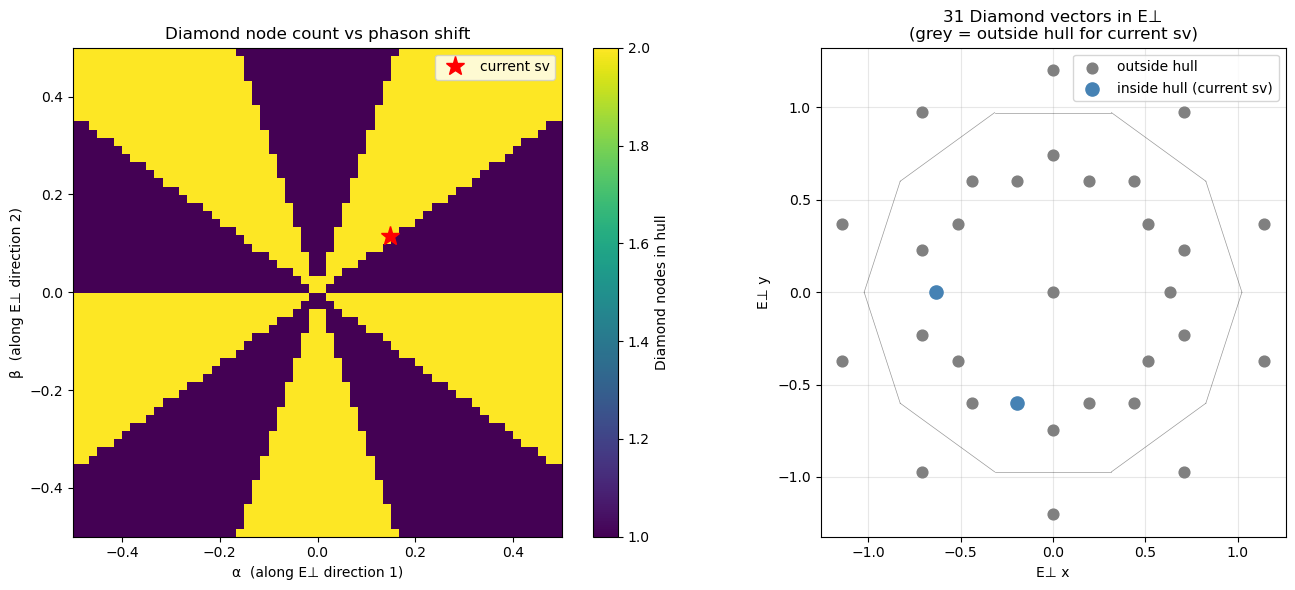

In [39]:
# --- Project all 31 Diamond vectors into E⊥ ---
d_perp = (y @ diamond_vecs.T).T          # (31, 3)  in the 3D perpendicular space

# --- Theoretical maximum: anchor the hull on each Diamond vector in turn ---
hull_centre_perp = y @ np.full(5, 0.5)

best_anchor, best_n, best_sv = None, 0, None
anchor_counts = []

for k, dv in enumerate(diamond_vecs):
    # shift so that diamond_vecs[k] maps to the hull centre
    sv_k = np.full(5, 0.5) - dv
    sv_k -= sv_k.mean()                  # enforce Σ = 0 (project onto A₄ hyperplane)
    projected = (y @ (diamond_vecs + sv_k).T).T
    cnt = int((hull_delaunay.find_simplex(projected) >= 0).sum())
    anchor_counts.append(cnt)
    if cnt > best_n:
        best_n   = cnt
        best_sv  = sv_k
        best_anchor = k

print(f'Theoretical maximum (anchor search): {best_n} Diamond nodes')
print(f'Best anchor vector : {diamond_vecs[best_anchor].astype(int)}')
print(f'Corresponding sv   : {np.round(best_sv, 6)}')
print(f'Current baseline   : {baseline}')
print()
if best_n == baseline:
    print('→ Current shift already achieves the theoretical maximum.')
    print('  The hull is too small to contain more Diamond nodes simultaneously.')
    print('  Consider enlarging d (lattice range) or scaling the Delaunay cell.')
else:
    print(f'→ {best_n - baseline} additional Diamond node(s) reachable.')
    print(f'  Use shiftVector = np.array({list(np.round(best_sv, 6))})')

# --- Fine grid search over the 2D E⊥ phason plane ---
e_perp_1 = y[0]
e_perp_2 = y[1]

N_grid = 60
alphas = np.linspace(-0.5, 0.5, N_grid)
betas  = np.linspace(-0.5, 0.5, N_grid)
count_grid = np.zeros((N_grid, N_grid), dtype=int)

for ia, a in enumerate(alphas):
    for ib, b in enumerate(betas):
        sv_ab = a * e_perp_1 + b * e_perp_2
        sv_ab -= sv_ab.mean()
        projected = (y @ (diamond_vecs + sv_ab).T).T
        count_grid[ia, ib] = (hull_delaunay.find_simplex(projected) >= 0).sum()

print(f'\nGrid search maximum : {count_grid.max()}')
print(f'Grid search minimum : {count_grid.min()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heat-map
im = axes[0].imshow(count_grid, origin='lower',
                    extent=[-0.5, 0.5, -0.5, 0.5],
                    aspect='equal', cmap='viridis')
plt.colorbar(im, ax=axes[0], label='Diamond nodes in hull')
axes[0].set_xlabel('α  (along E⊥ direction 1)')
axes[0].set_ylabel('β  (along E⊥ direction 2)')
axes[0].set_title('Diamond node count vs phason shift')

sv_cur_ab_a = np.dot(shiftVector, e_perp_1)
sv_cur_ab_b = np.dot(shiftVector, e_perp_2)
axes[0].plot(sv_cur_ab_b, sv_cur_ab_a, 'r*', markersize=14, label='current sv')
axes[0].legend()

# Scatter: Diamond vectors in E⊥ (first two of three coords)
cur_projected = (y @ (diamond_vecs + shiftVector).T).T
in_hull_mask  = hull_delaunay.find_simplex(cur_projected) >= 0

axes[1].scatter(d_perp[~in_hull_mask, 0], d_perp[~in_hull_mask, 1],
                c='grey', s=60, label='outside hull', zorder=2)
axes[1].scatter(d_perp[in_hull_mask,  0], d_perp[in_hull_mask,  1],
                c='steelblue', s=90, label='inside hull (current sv)', zorder=3)

# Hull boundary: convexHullSeed is already in 3D — just take first two coords
hull_2d_pts = convexHullSeed[hull.vertices][:, :2]
from scipy.spatial import ConvexHull as CH2
try:
    ch2 = CH2(hull_2d_pts)
    for s in ch2.simplices:
        axes[1].plot(hull_2d_pts[s, 0], hull_2d_pts[s, 1], 'k-', lw=0.5, alpha=0.4)
except Exception:
    pass

axes[1].set_aspect('equal')
axes[1].set_xlabel('E⊥ x')
axes[1].set_ylabel('E⊥ y')
axes[1].set_title('31 Diamond vectors in E⊥\n(grey = outside hull for current sv)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Optimise shiftVector to maximise Eikosany nodes — and diagnostic

The 20 Eikosany lattice vectors have coordinates in {0,1} with sum 2 or 3:
- **sum = 2** (C(5,2) = 10): products of 2 non-unity generators with "1" as the third
- **sum = 3** (C(5,3) = 10): products of 3 non-unity generators

Because all coordinates are non-negative, these vectors cluster naturally near the
interior of the [0,1]⁵ hypercube hull — unlike the Diamond roots which straddle it.
We expect to recover a larger fraction of the Eikosany than the Diamond.

Eikosany lattice vectors: 20  (expect 20)
Baseline Eikosany count (current shiftVector): 13

Optimal shiftVector : [-0.36844  -0.491094  0.315972  0.430247  0.113314]
Eikosany nodes found: 13  (baseline: 13)
Improvement         : 0

To use: replace shiftVector in the cell above with
  shiftVector = np.array([np.float64(-0.36844), np.float64(-0.491094), np.float64(0.315972), np.float64(0.430247), np.float64(0.113314)])

Theoretical maximum (anchor search): 13 Eikosany nodes
Best anchor vector : [1 1 0 0 0]
→ Optimisation reached the theoretical maximum.

Grid search maximum : 13
Grid search minimum : 10


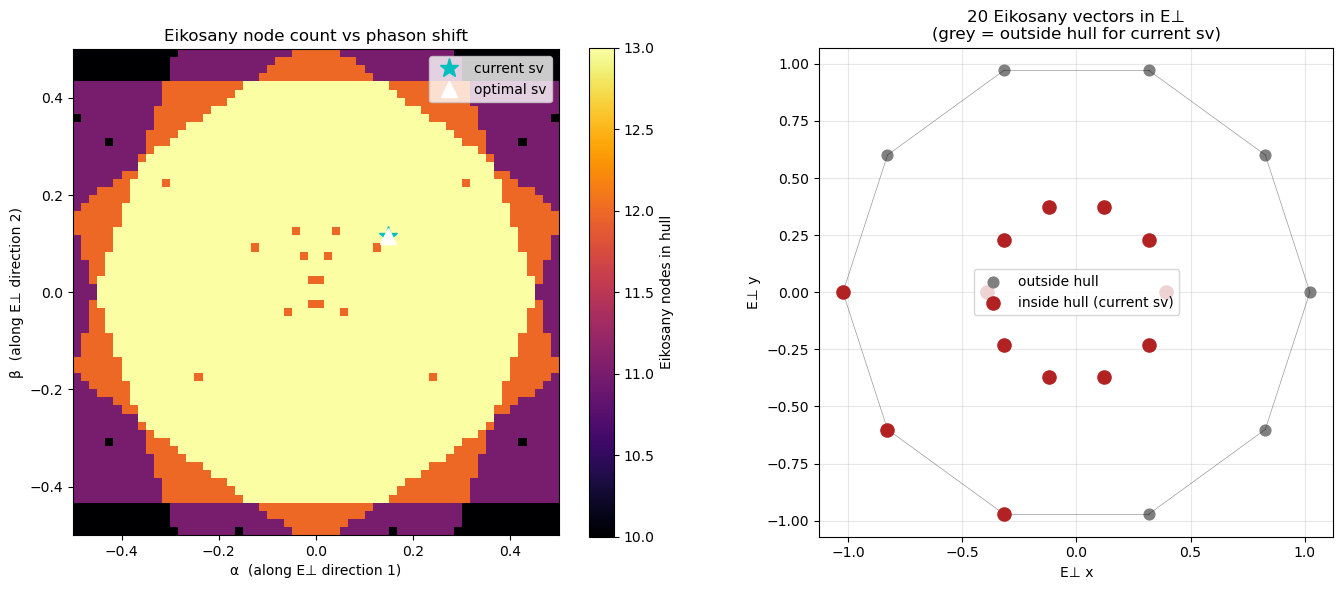

In [40]:
# --- Build the 20 Eikosany lattice vectors in ℤ⁵ ---
# Coordinates in {0,1}, sum in {2,3}
from itertools import combinations

eiko_vecs = []
for r in (2, 3):
    for indices in combinations(range(5), r):
        v = [0]*5
        for i in indices:
            v[i] = 1
        eiko_vecs.append(v)

eiko_vecs = np.array(eiko_vecs, dtype=float)   # (20, 5)
print(f'Eikosany lattice vectors: {len(eiko_vecs)}  (expect 20)')

# hull_delaunay already built in Diamond optimisation cell above

# --- Objective ---
def neg_eiko_count(sv_free):
    sv = np.append(sv_free, -sv_free.sum())
    projected = (y @ (eiko_vecs + sv).T).T
    return -(hull_delaunay.find_simplex(projected) >= 0).sum()

# --- Baseline ---
eiko_baseline = -int(neg_eiko_count(shiftVector[:4]))
print(f'Baseline Eikosany count (current shiftVector): {eiko_baseline}')

# --- Global optimisation ---
bounds = [(-0.5, 0.5)] * 4

eiko_result = differential_evolution(
    neg_eiko_count,
    bounds,
    seed    = 42,
    maxiter = 500,
    popsize = 20,
    tol     = 0,
    polish  = True,
    disp    = False,
)

sv_eiko_free = eiko_result.x
sv_eiko      = np.append(sv_eiko_free, -sv_eiko_free.sum())
eiko_best    = -int(eiko_result.fun)

print(f'\nOptimal shiftVector : {np.round(sv_eiko, 6)}')
print(f'Eikosany nodes found: {eiko_best}  (baseline: {eiko_baseline})')
print(f'Improvement         : {eiko_best - eiko_baseline}')
print(f'\nTo use: replace shiftVector in the cell above with')
print(f'  shiftVector = np.array({list(np.round(sv_eiko, 6))})')

# --- Theoretical maximum: anchor search ---
eiko_best_anchor, eiko_best_n, eiko_best_sv = None, 0, None
for k, dv in enumerate(eiko_vecs):
    sv_k = np.full(5, 0.5) - dv
    sv_k -= sv_k.mean()
    projected = (y @ (eiko_vecs + sv_k).T).T
    cnt = int((hull_delaunay.find_simplex(projected) >= 0).sum())
    if cnt > eiko_best_n:
        eiko_best_n   = cnt
        eiko_best_sv  = sv_k
        eiko_best_anchor = k

print(f'\nTheoretical maximum (anchor search): {eiko_best_n} Eikosany nodes')
print(f'Best anchor vector : {eiko_vecs[eiko_best_anchor].astype(int)}')
if eiko_best_n == eiko_best:
    print('→ Optimisation reached the theoretical maximum.')
else:
    print(f'→ Anchor search found {eiko_best_n - eiko_best} more — try:')
    print(f'  shiftVector = np.array({list(np.round(eiko_best_sv, 6))})')

# --- Fine grid search and plots ---
e_perp_1 = y[0]
e_perp_2 = y[1]

N_grid = 60
alphas = np.linspace(-0.5, 0.5, N_grid)
betas  = np.linspace(-0.5, 0.5, N_grid)
eiko_count_grid = np.zeros((N_grid, N_grid), dtype=int)

for ia, a in enumerate(alphas):
    for ib, b in enumerate(betas):
        sv_ab = a * e_perp_1 + b * e_perp_2
        sv_ab -= sv_ab.mean()
        projected = (y @ (eiko_vecs + sv_ab).T).T
        eiko_count_grid[ia, ib] = (hull_delaunay.find_simplex(projected) >= 0).sum()

print(f'\nGrid search maximum : {eiko_count_grid.max()}')
print(f'Grid search minimum : {eiko_count_grid.min()}')

# --- Plots ---
eiko_perp     = (y @ eiko_vecs.T).T          # (20, 3) in E⊥
cur_eiko_proj = (y @ (eiko_vecs + shiftVector).T).T
eiko_in_hull  = hull_delaunay.find_simplex(cur_eiko_proj) >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heat-map
im = axes[0].imshow(eiko_count_grid, origin='lower',
                    extent=[-0.5, 0.5, -0.5, 0.5],
                    aspect='equal', cmap='inferno')
plt.colorbar(im, ax=axes[0], label='Eikosany nodes in hull')
axes[0].set_xlabel('α  (along E⊥ direction 1)')
axes[0].set_ylabel('β  (along E⊥ direction 2)')
axes[0].set_title('Eikosany node count vs phason shift')

sv_cur_a = np.dot(shiftVector, e_perp_1)
sv_cur_b = np.dot(shiftVector, e_perp_2)
axes[0].plot(sv_cur_b, sv_cur_a, 'c*', markersize=14, label='current sv')

sv_opt_a = np.dot(sv_eiko, e_perp_1)
sv_opt_b = np.dot(sv_eiko, e_perp_2)
axes[0].plot(sv_opt_b, sv_opt_a, 'w^', markersize=12, label='optimal sv')
axes[0].legend()

# Scatter in E⊥
axes[1].scatter(eiko_perp[~eiko_in_hull, 0], eiko_perp[~eiko_in_hull, 1],
                c='grey', s=60, label='outside hull', zorder=2)
axes[1].scatter(eiko_perp[eiko_in_hull,  0], eiko_perp[eiko_in_hull,  1],
                c='firebrick', s=90, label='inside hull (current sv)', zorder=3)

hull_2d_pts = convexHullSeed[hull.vertices][:, :2]
try:
    ch2 = CH2(hull_2d_pts)
    for s in ch2.simplices:
        axes[1].plot(hull_2d_pts[s, 0], hull_2d_pts[s, 1], 'k-', lw=0.5, alpha=0.4)
except Exception:
    pass

axes[1].set_aspect('equal')
axes[1].set_xlabel('E⊥ x')
axes[1].set_ylabel('E⊥ y')
axes[1].set_title('20 Eikosany vectors in E⊥\n(grey = outside hull for current sv)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()